In [7]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from tqdm import tqdm
import imagej

ij = imagej.init()

jar tool not found at /Users/maxwatzky/Library/Caches/cjdk/v0/jdks/c9b683d3b609f013dcf9691a5f51d488b3111ddb/zulu11.90.19-ca-jre11.0.32-macosx_aarch64/Contents/Home/bin/jar


[DEBUG] Creating service: org.scijava.event.DefaultEventService
[DEBUG] Creating service: org.scijava.log.StderrLogService
[DEBUG] Created service 'org.scijava.log.StderrLogService' in 0 ms
[DEBUG] Creating service: org.scijava.thread.DefaultThreadService
[DEBUG] Created service 'org.scijava.thread.DefaultThreadService' in 1 ms
[DEBUG] Created service 'org.scijava.event.DefaultEventService' in 115 ms
[DEBUG] Creating service: org.scijava.app.DefaultAppService
[DEBUG] Creating service: org.scijava.plugin.DefaultPluginService
[DEBUG] Found 1748 plugins.
[DEBUG] - class='net.imagej.plugins.tools.KonamiHandler', name='Konami', priority=Infinity, enabled=true, pluginType=Tool
[DEBUG] - class='org.scijava.module.process.DebugPostprocessor', priority=1.0E300, enabled=true, pluginType=PostprocessorPlugin
[DEBUG] - class='org.scijava.module.process.DebugPreprocessor', priority=1.0E300, enabled=true, pluginType=PreprocessorPlugin
[DEBUG] - class='net.imagej.legacy.SingleInstanceArgument', priori

In [9]:
def get_tif_file(path):
    data = ij.io().open(path)
    return ij.py.from_java(data).data

In [49]:
real_imgs = []
zs = np.array([-6, 0, 2, 4])
for i, z in enumerate(zs):
    zero_img = 0
    if z == 0:
        zero_img = get_tif_file("real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_00001.tif")

    if z == -6:
        zero_img = get_tif_file("real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_neg6_00001.tif")

    if z == 2:
        zero_img = get_tif_file("real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_pos2_00001.tif")

    if z == 4:
        zero_img = get_tif_file("real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_pos4_00001.tif")
    real_imgs.append(zero_img)
real_imgs = np.array(real_imgs).astype(float)
real_imgs = real_imgs - np.min(real_imgs)

[DEBUG] publish(
	context = org.scijava.Context@15f30085
	consumed = false
	progress = -1
	maximum = -1
	status = Initializing FileLocation:file:/Users/maxwatzky/Documents/GitHub/fall_2026_lab/optimization/real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_neg6_00001.tif
	warning = false,null,null), called from non-EDT Thread:null
[DEBUG] Reading IFDs
[DEBUG] Populating metadata
[DEBUG] Checking comment style
[DEBUG] publish(
	context = org.scijava.Context@15f30085
	consumed = false
	progress = -1
	maximum = -1
	status = FileLocation:file:/Users/maxwatzky/Documents/GitHub/fall_2026_lab/optimization/real_image_data/mode1/fluobead_1um_zoom_99p9x_SP_6p0mW_SS_0p25um_512x512_Avg20_pat_1_neg6_00001.tif: read 1 planes in 0.0s
	warning = false,null,null), called from non-EDT Thread:null
[DEBUG] publish(
	context = org.scijava.Context@15f30085
	consumed = false
	location = FileLocation:file:/Users/maxwatzky/Documents/GitHub/fall_2026_lab/optimization/real_image

In [50]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [62]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [139]:
true_modes = [[2,2], [0,4]]
true_strengths = [-0.3, -0.5]

microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)


xs, ys = grid.get_xy()

In [140]:
true_aberration = zernike.Aberration(true_modes, true_strengths)

In [141]:
eps = 0.0000001
z_sample_levels = np.arange(-6 * 1e-3, 6 * 1e-3 + eps, 0.00020)
z_image_levels =  zs * 1e-3

In [142]:
#bin the images:
binned_imgs = []
for i, im in enumerate(real_imgs):
    new_img = np.zeros((64, 64))
    for k in range(0, 64):
        for l in range(0, 64):
            new_img[k, l] = np.mean(im[k*8:(k+1)*8,l*8:(l+1)*8, ])

    binned_imgs.append(new_img)

In [152]:
from optimization import reconstruction

reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = binned_imgs,
                                  focal_z_levels = z_image_levels,
                                  sample_z_levels = z_sample_levels,
                                  aberration = true_aberration,
                                  rho = 1e48,
                                  mode = "vector")


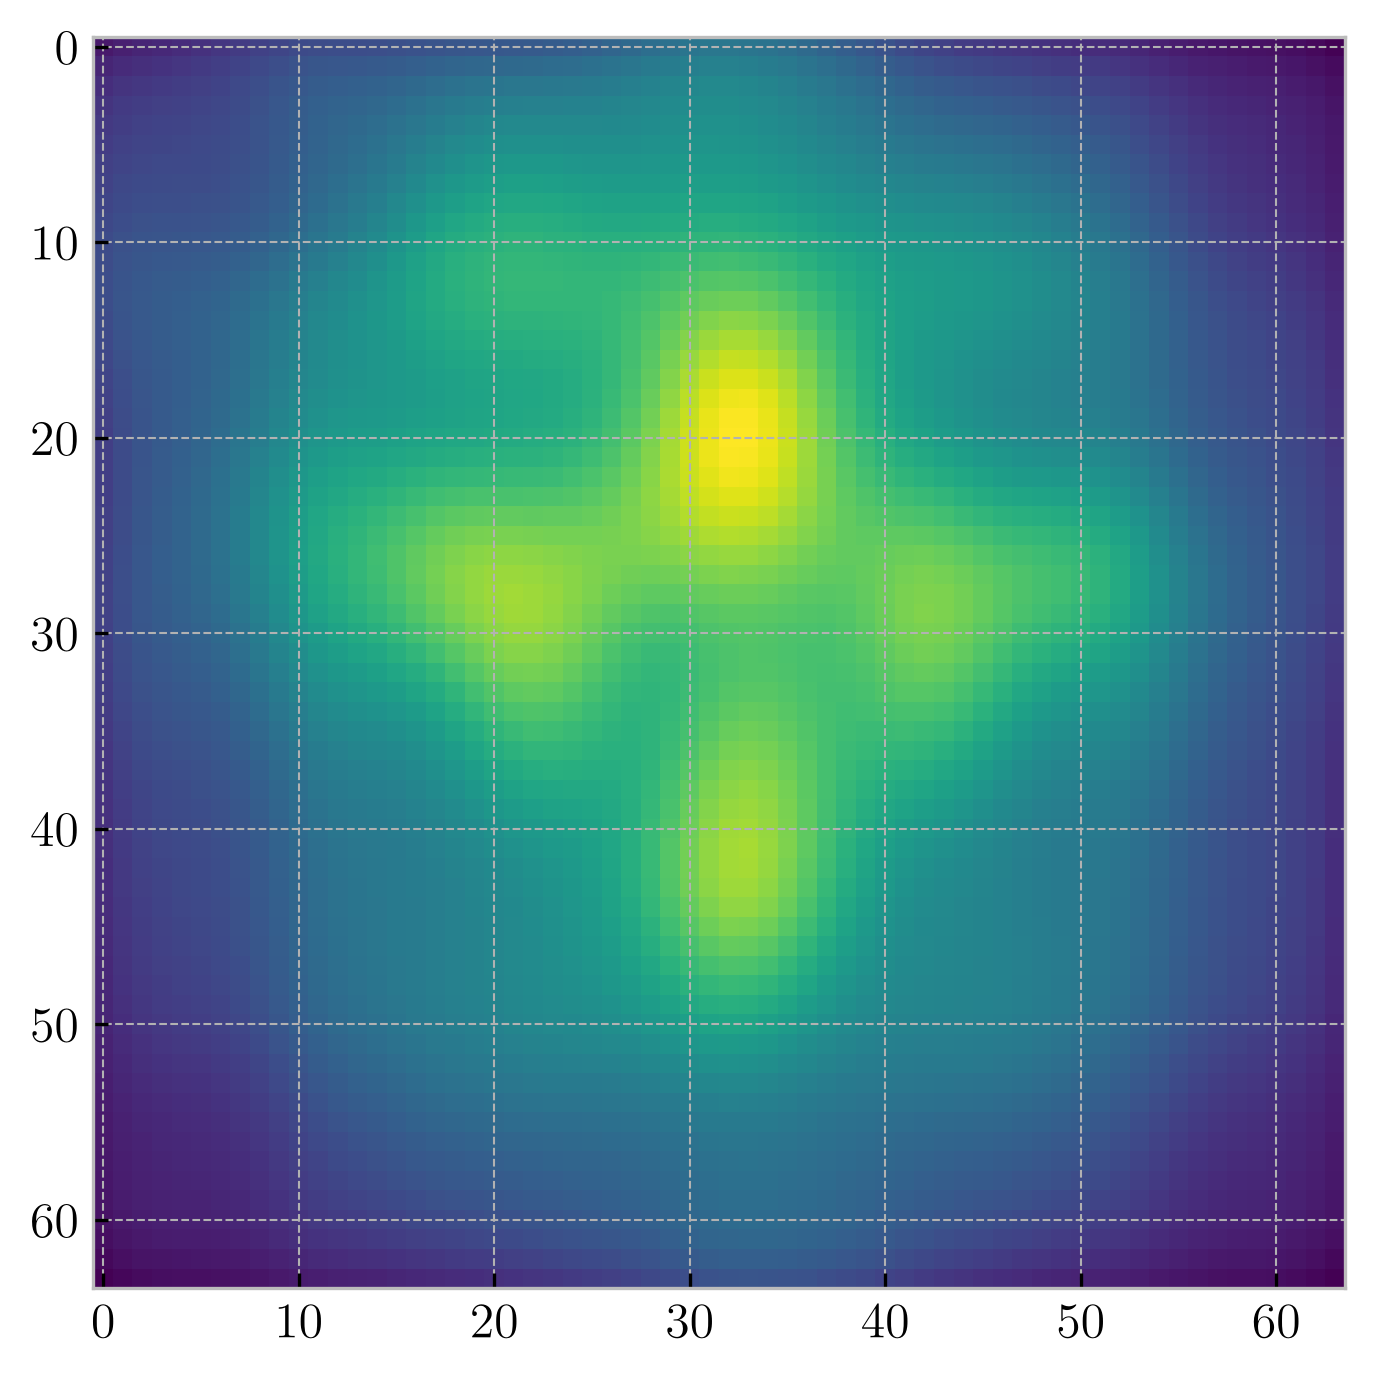

In [153]:
plt.imshow(reconstructed_img.image_mask[int(len(reconstructed_img.image_mask)/2)])

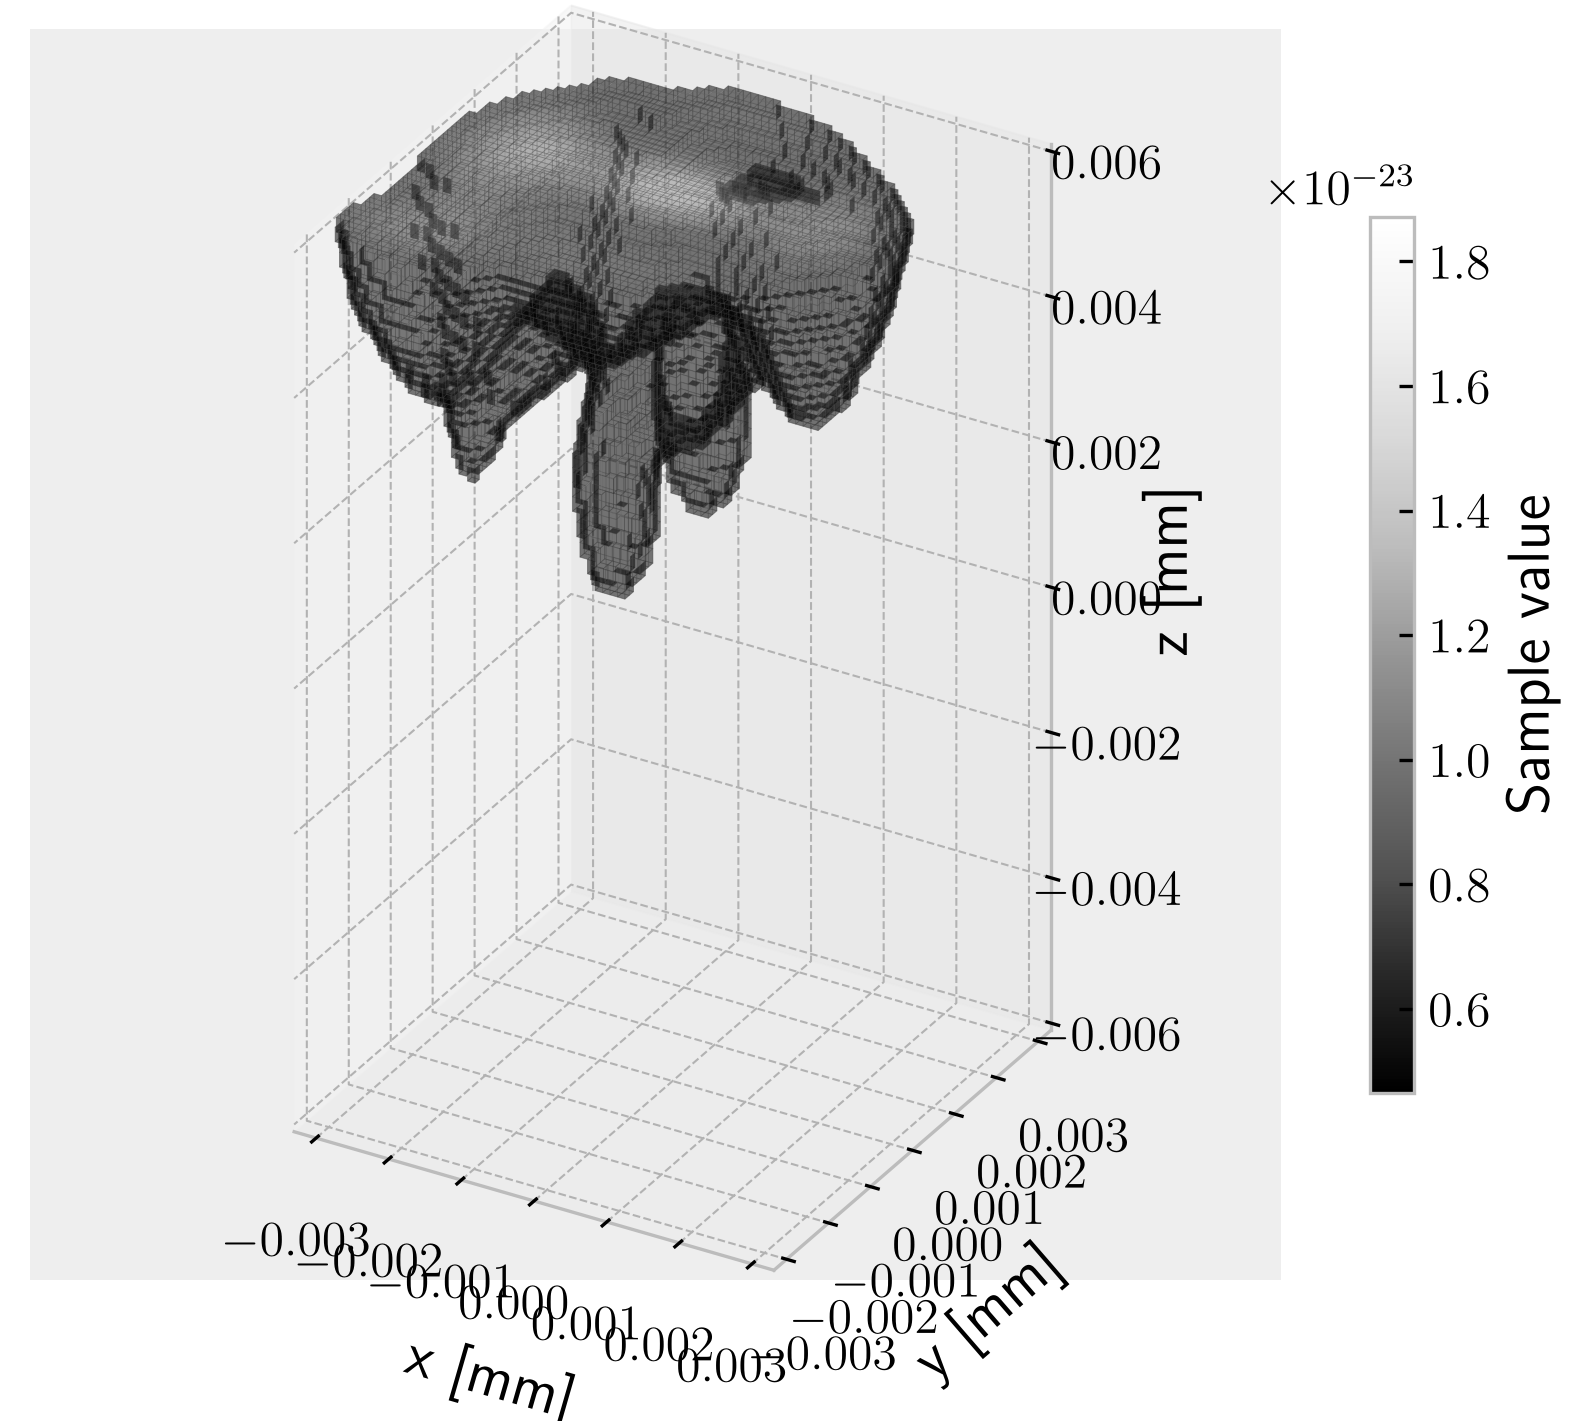

In [154]:
fig, ax = plotting.plot_sample_3D(reconstructed_img, np.percentile(reconstructed_img.image_mask,92))

In [92]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=binned_imgs,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes= true_modes,
    rho=1e54,
    initial_strengths=[0.0] * len(true_modes),
)

Iteration 0: loss=7.1428928624e+11, strengths (waves)=[0. 0.]
Iteration 1: loss=7.1428570861e+11, strengths (waves)=[-0.00081573 -0.00082314]
Iteration 2: loss=7.1428570861e+11, strengths (waves)=[-0.00081551 -0.00082278]
Stopped: Gradient and curvature tolerances satisfied.
